# WTI MM Net COT — HMM Regime Detection

Fit a Gaussian Hidden Markov Model to the weekly MM Net positioning
changes to identify latent regimes in speculative behaviour.

Questions:
- How many regimes exist in MM positioning dynamics?
- Do they correspond to economic regimes (bull/bear, high/low vol)?
- Is the regime state persistent or rapidly switching?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hmmlearn.hmm import GaussianHMM
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load data

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
WTI_CODES = ['067651', '067411']
wti_raw = raw[raw['cftc_contract_market_code'].isin(WTI_CODES)].copy()
wti_raw['as_of_date'] = pd.to_datetime(wti_raw['report_date_as_yyyy_mm_dd'])

_SUM_COLS = ['open_interest_all',
             'm_money_positions_long_all', 'm_money_positions_short_all']
for c in _SUM_COLS:
    wti_raw[c] = pd.to_numeric(wti_raw[c], errors='coerce')

wti = wti_raw.groupby('as_of_date')[_SUM_COLS].sum().reset_index()
wti['mm_net'] = wti['m_money_positions_long_all'] - wti['m_money_positions_short_all']
wti['mm_net_oi'] = wti['mm_net'] / wti['open_interest_all'] * 100
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

# Weekly changes
wti['mm_net_chg'] = wti['mm_net'].diff()
wti['mm_net_oi_chg'] = wti['mm_net_oi'].diff()
wti.dropna(subset=['mm_net_chg'], inplace=True)
wti.reset_index(drop=True, inplace=True)

dates = wti['as_of_date'].values
print(f'Rows: {len(wti)}, Range: {pd.Timestamp(dates[0]).date()} -> {pd.Timestamp(dates[-1]).date()}')

Rows: 1032, Range: 2006-06-20 -> 2026-03-24


## 2. Also load prices for context

In [3]:
prices = pd.read_csv('../../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

# Join Friday close price to each COT week
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')

wti = pd.merge_asof(
    wti.sort_values('release_date'),
    prices.rename(columns={'tradeDate': 'release_date'}),
    on='release_date', direction='backward', tolerance=pd.Timedelta(days=3),
)
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)
wti['price_ret'] = wti['F1_RolledPrice'].pct_change() * 100

dates = wti['as_of_date'].values
print(f'With prices: {len(wti)} rows')

With prices: 1032 rows


## 3. Model selection: 2 vs 3 vs 4 states

In [4]:
# Fit HMM on MM net change (univariate)
X = wti['mm_net_chg'].values.reshape(-1, 1)

results = {}
for n in [2, 3, 4]:
    best_score = -np.inf
    best_model = None
    # Multiple restarts to avoid local optima
    for seed in range(10):
        model = GaussianHMM(
            n_components=n,
            covariance_type='full',
            n_iter=200,
            random_state=seed,
        )
        model.fit(X)
        score = model.score(X)
        if score > best_score:
            best_score = score
            best_model = model
    results[n] = {'model': best_model, 'loglik': best_score,
                  'aic': -2 * best_score + 2 * (n**2 + 2*n - 1),
                  'bic': -2 * best_score + np.log(len(X)) * (n**2 + 2*n - 1)}
    print(f'{n} states: loglik={best_score:.1f}, AIC={results[n]["aic"]:.1f}, BIC={results[n]["bic"]:.1f}')

# Select by BIC
best_n = min(results, key=lambda n: results[n]['bic'])
print(f'\nBest by BIC: {best_n} states')

2 states: loglik=-11825.5, AIC=23665.0, BIC=23699.6


3 states: loglik=-11816.3, AIC=23660.7, BIC=23729.8


4 states: loglik=-11806.3, AIC=23658.5, BIC=23772.1

Best by BIC: 2 states


## 4. Fitted regime parameters

In [5]:
model = results[best_n]['model']
states = model.predict(X)
probs = model.predict_proba(X)

# Sort states by mean (ascending)
means = model.means_.flatten()
order = np.argsort(means)
state_map = {old: new for new, old in enumerate(order)}
states_sorted = np.array([state_map[s] for s in states])

print(f'Model: {best_n} states')
print(f'\nTransition matrix (sorted by mean):')
T = model.transmat_[np.ix_(order, order)]
print(pd.DataFrame(T, index=[f'From {i}' for i in range(best_n)],
                   columns=[f'To {i}' for i in range(best_n)]).round(3).to_string())

print(f'\nState parameters:')
for i in range(best_n):
    orig = order[i]
    m = model.means_[orig, 0]
    s = np.sqrt(model.covars_[orig, 0, 0])
    n_weeks = (states_sorted == i).sum()
    pct = n_weeks / len(states_sorted) * 100
    persistence = T[i, i]
    avg_duration = 1 / (1 - persistence) if persistence < 1 else np.inf
    print(f'  State {i}: mean={m:+10,.0f}  std={s:10,.0f}  '
          f'freq={pct:5.1f}%  persistence={persistence:.3f}  avg_duration={avg_duration:.1f}w')

Model: 2 states

Transition matrix (sorted by mean):
         To 0   To 1
From 0  0.978  0.022
From 1  0.021  0.979

State parameters:
  State 0: mean=      -204  std=    30,434  freq= 43.4%  persistence=0.978  avg_duration=44.9w
  State 1: mean=      +373  std=    16,336  freq= 56.6%  persistence=0.979  avg_duration=47.7w


## 5. Regime timeline

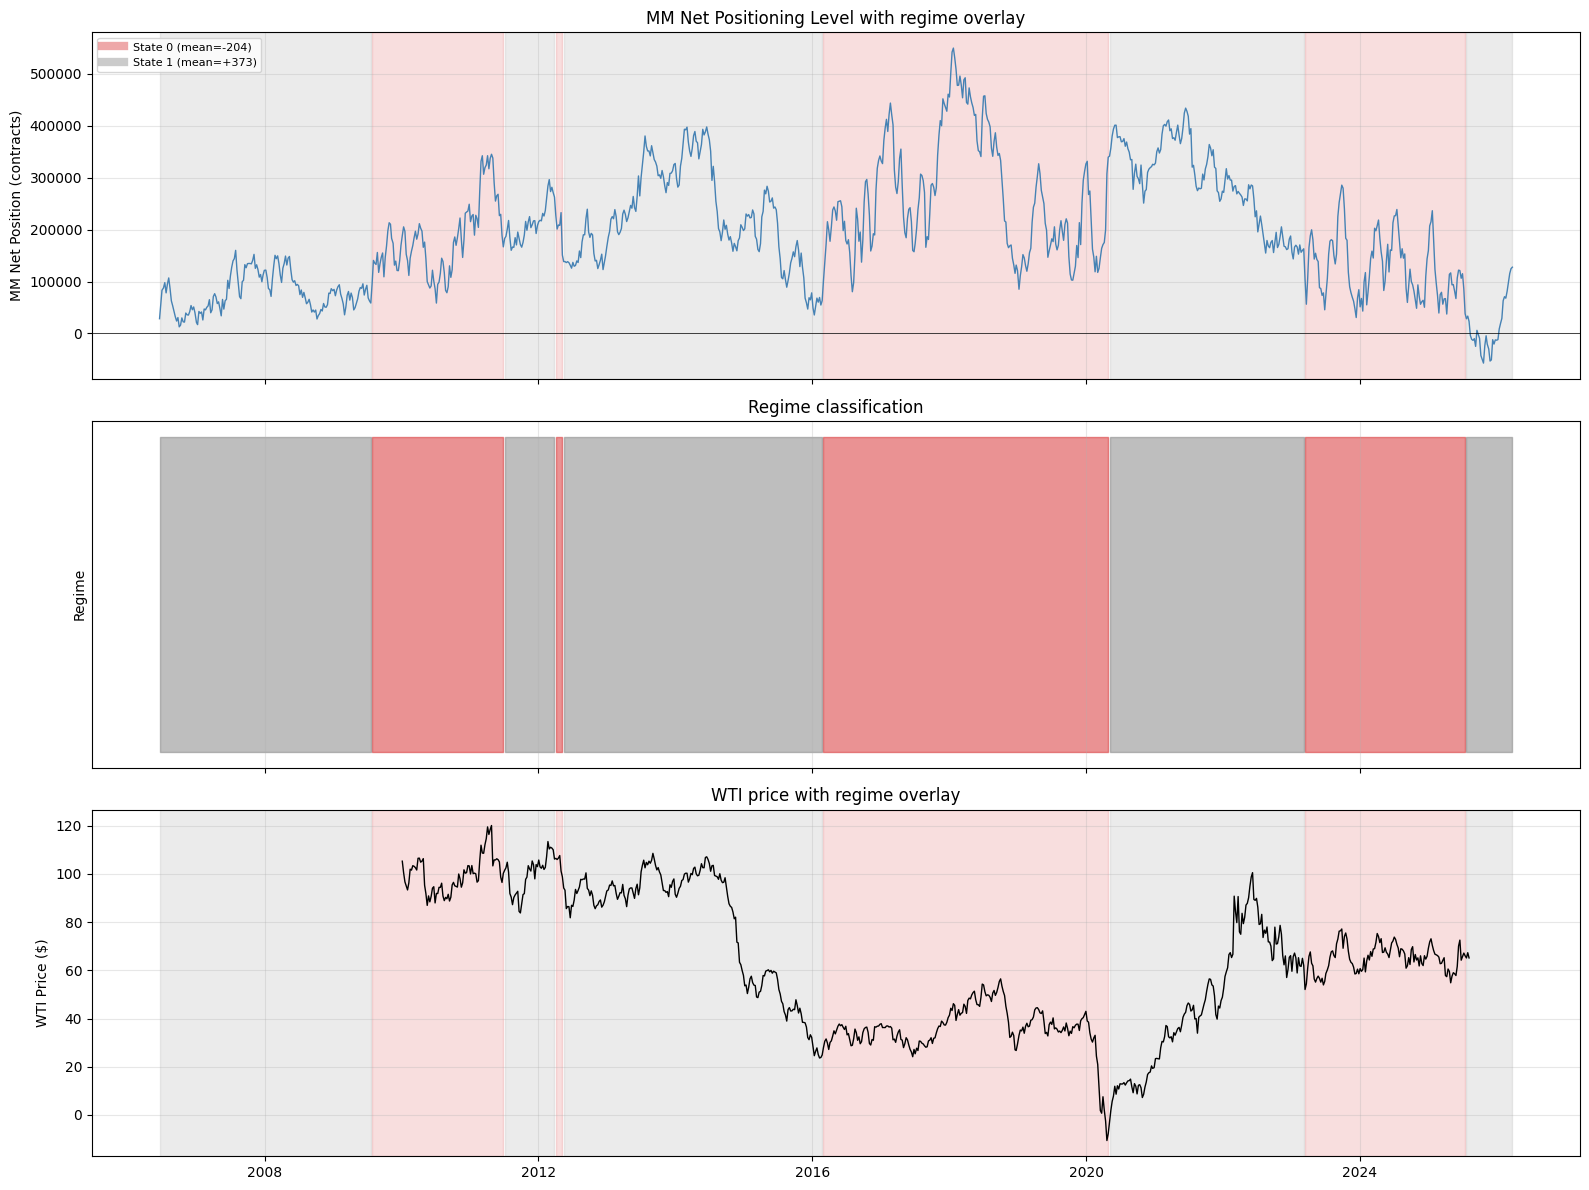

In [6]:
dt = pd.to_datetime(wti['as_of_date'])

REGIME_COLORS = ['tab:red', 'tab:grey', 'tab:blue', 'tab:green'][:best_n]
REGIME_LABELS = [f'State {i} (mean={model.means_[order[i],0]:+,.0f})' for i in range(best_n)]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: MM net level with regime background
ax = axes[0]
for j in range(best_n):
    mask = states_sorted == j
    ax.fill_between(dt, 0, 1, where=mask,
                    transform=ax.get_xaxis_transform(),
                    color=REGIME_COLORS[j], alpha=0.15, step='mid')
ax.plot(dt, wti['mm_net'], color='steelblue', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('MM Net Position (contracts)')
ax.set_title('MM Net Positioning Level with regime overlay')
# Manual legend for regimes
for j in range(best_n):
    ax.plot([], [], color=REGIME_COLORS[j], lw=6, alpha=0.4, label=REGIME_LABELS[j])
ax.legend(fontsize=8, loc='upper left')

# Panel 2: Regime state over time (colored band)
ax = axes[1]
for j in range(best_n):
    mask = states_sorted == j
    ax.fill_between(dt, 0, 1, where=mask,
                    color=REGIME_COLORS[j], alpha=0.5,
                    step='mid')
ax.set_ylabel('Regime')
ax.set_yticks([])
ax.set_title('Regime classification')

# Panel 3: Price with regime background
ax = axes[2]
for j in range(best_n):
    mask = states_sorted == j
    ax.fill_between(dt, 0, 1, where=mask,
                    transform=ax.get_xaxis_transform(),
                    color=REGIME_COLORS[j], alpha=0.15, step='mid')
ax.plot(dt, wti['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('WTI Price ($)')
ax.set_title('WTI price with regime overlay')

plt.tight_layout()
plt.show()


## 6. Regime characteristics

In [7]:
wti['regime'] = states_sorted

# Stats per regime
print('Per-regime statistics:\n')
for i in range(best_n):
    sub = wti[wti['regime'] == i]
    print(f'State {i} ({len(sub)} weeks, {len(sub)/len(wti)*100:.1f}%):')
    print(f'  MM net change:     mean={sub["mm_net_chg"].mean():+10,.0f}  '
          f'std={sub["mm_net_chg"].std():10,.0f}')
    print(f'  MM net/OI change:  mean={sub["mm_net_oi_chg"].mean():+.3f}%  '
          f'std={sub["mm_net_oi_chg"].std():.3f}%')
    print(f'  Price return:      mean={sub["price_ret"].mean():+.2f}%  '
          f'std={sub["price_ret"].std():.2f}%')
    print(f'  MM net level:      mean={sub["mm_net"].mean():+10,.0f}  '
          f'range=[{sub["mm_net"].min():+,.0f}, {sub["mm_net"].max():+,.0f}]')
    print(f'  Price level:       mean=${sub["F1_RolledPrice"].mean():.1f}  '
          f'range=[${sub["F1_RolledPrice"].min():.1f}, ${sub["F1_RolledPrice"].max():.1f}]')
    print()

Per-regime statistics:

State 0 (448 weeks, 43.4%):
  MM net change:     mean=      +330  std=    31,044
  MM net/OI change:  mean=+0.000%  std=0.933%
  Price return:      mean=+1.85%  std=50.09%
  MM net level:      mean=  +207,780  range=[+30,623, +549,602]
  Price level:       mean=$57.0  range=[$-10.6, $120.1]

State 1 (584 weeks, 56.6%):
  MM net change:     mean=       -87  std=    17,258
  MM net/OI change:  mean=+0.002%  std=0.612%
  Price return:      mean=+0.48%  std=15.32%
  MM net level:      mean=  +186,209  range=[-57,141, +433,970]
  Price level:       mean=$69.0  range=[$-2.8, $113.5]



## 7. Lead/lag by regime

Does the price → MM trend-following relationship change across regimes?

In [8]:
mm_all = wti['mm_net_chg'].values
pr_all = wti['price_ret'].values

def spearman_lag(x, y, k):
    """Spearman corr(x[t], y[t+k]), handling NaN."""
    n = len(x)
    if k == 0:
        a, b = x, y
    elif k > 0:
        a, b = x[:n-k], y[k:]
    else:
        a, b = x[-k:], y[:n+k]
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 20:
        return float('nan')
    return sp_stats.spearmanr(a[mask], b[mask]).statistic

print(f'{"Regime":>8s}  {"n":>4s}  {"lag -1":>8s}  {"lag 0":>8s}  {"lag +1":>8s}')
print('-' * 45)

for i in range(best_n):
    idx = np.where(states_sorted == i)[0]
    mm_r = mm_all[idx]
    pr_r = pr_all[idx]
    r = {k: spearman_lag(mm_r, pr_r, k) for k in [-1, 0, 1]}
    print(f'State {i:>2d}  {len(idx):>4d}  {r[-1]:>+8.3f}  {r[0]:>+8.3f}  {r[1]:>+8.3f}')

r_all = {k: spearman_lag(mm_all, pr_all, k) for k in [-1, 0, 1]}
print(f'{"All":>8s}  {len(mm_all):>4d}  {r_all[-1]:>+8.3f}  {r_all[0]:>+8.3f}  {r_all[1]:>+8.3f}')


  Regime     n    lag -1     lag 0    lag +1
---------------------------------------------
State  0   448    +0.510    +0.214    -0.014
State  1   584    +0.351    +0.283    -0.023
     All  1032    +0.442    +0.233    -0.010


## 8. Multivariate HMM: MM net change + price return

Fit jointly on both series to see if the HMM identifies
regimes in the *relationship* between price and positioning.

In [9]:
# Standardise both series
mm_std = (wti['mm_net_chg'] - wti['mm_net_chg'].mean()) / wti['mm_net_chg'].std()
pr_std = (wti['price_ret'] - wti['price_ret'].mean()) / wti['price_ret'].std()
X2 = np.column_stack([mm_std.values, pr_std.values])
X2 = X2[~np.isnan(X2).any(axis=1)]  # drop NaN

results_mv = {}
for n in [2, 3]:
    best_score = -np.inf
    best_model = None
    for seed in range(10):
        m = GaussianHMM(n_components=n, covariance_type='full',
                        n_iter=200, random_state=seed)
        m.fit(X2)
        score = m.score(X2)
        if score > best_score:
            best_score = score
            best_model = m
    n_params = n**2 + n*2 + n*3 - 1  # transitions + means + covariance
    results_mv[n] = {'model': best_model, 'loglik': best_score,
                     'bic': -2*best_score + np.log(len(X2)) * n_params}
    print(f'{n} states: loglik={best_score:.1f}, BIC={results_mv[n]["bic"]:.1f}')

best_n_mv = min(results_mv, key=lambda n: results_mv[n]['bic'])
model_mv = results_mv[best_n_mv]['model']
states_mv = model_mv.predict(X2)

# Sort by mean MM change
means_mv = model_mv.means_[:, 0]
order_mv = np.argsort(means_mv)
state_map_mv = {old: new for new, old in enumerate(order_mv)}
states_mv_sorted = np.array([state_map_mv[s] for s in states_mv])

print(f'\nBest by BIC: {best_n_mv} states')
print(f'\nState parameters (standardised scale):')
for i in range(best_n_mv):
    orig = order_mv[i]
    m = model_mv.means_[orig]
    cov = model_mv.covars_[orig]
    corr = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    n_w = (states_mv_sorted == i).sum()
    print(f'  State {i}: mean_mm={m[0]:+.2f} mean_price={m[1]:+.2f}  '
          f'corr(mm,price)={corr:+.2f}  freq={n_w/len(states_mv)*100:.1f}%')

2 states: loglik=-1845.0, BIC=3777.7


3 states: loglik=-888.0, BIC=1930.9

Best by BIC: 3 states

State parameters (standardised scale):
  State 0: mean_mm=-0.02 mean_price=-0.03  corr(mm,price)=+0.24  freq=96.1%
  State 1: mean_mm=+0.29 mean_price=-0.08  corr(mm,price)=+0.38  freq=3.8%
  State 2: mean_mm=+0.30 mean_price=+25.22  corr(mm,price)=+1.00  freq=0.1%


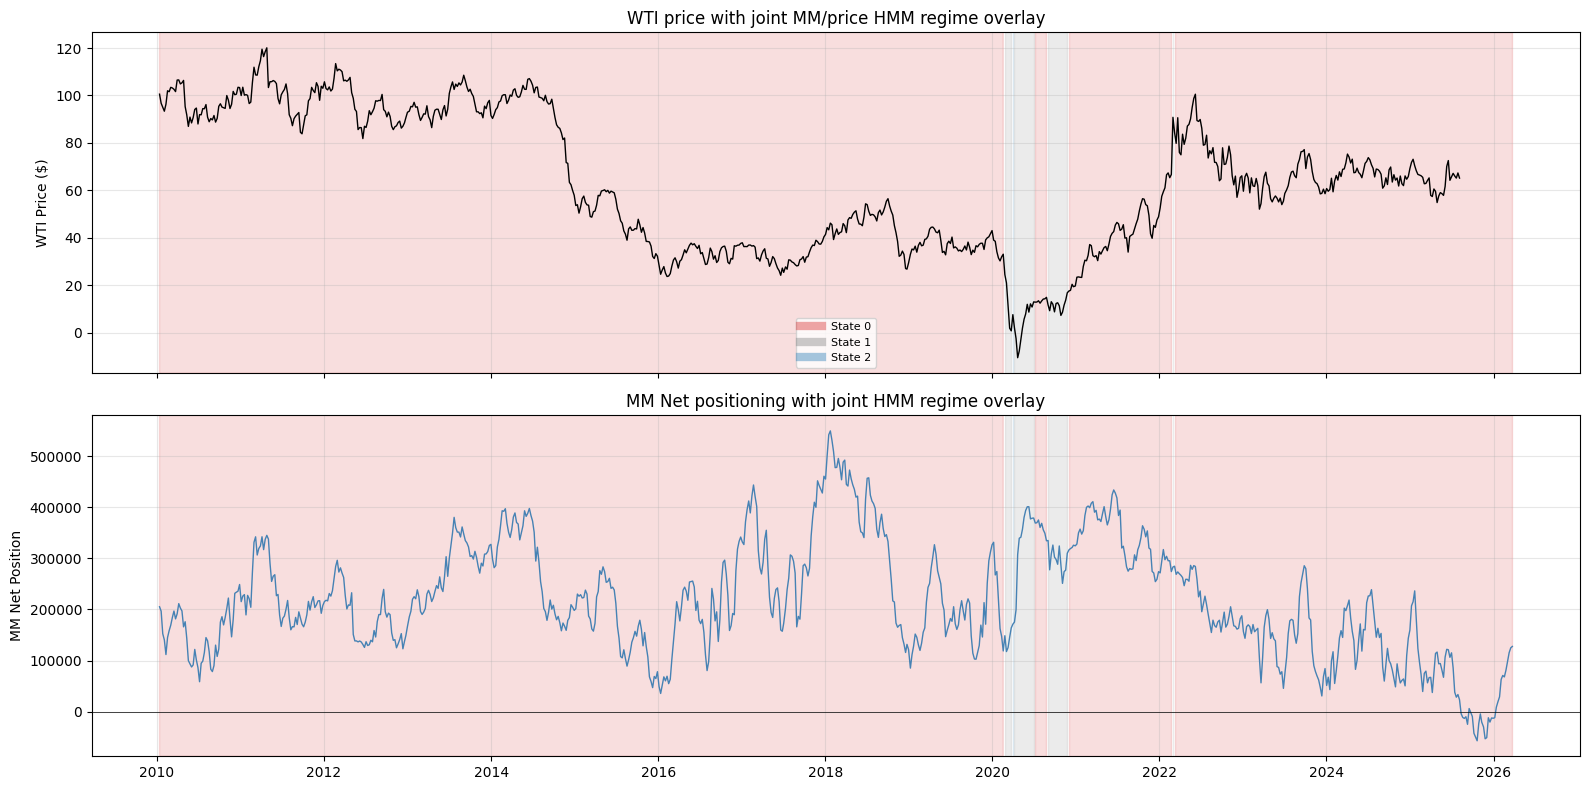

In [10]:
# Timeline with multivariate regimes
valid = wti.dropna(subset=['price_ret']).reset_index(drop=True)
n_states_mv = len(states_mv_sorted)
valid = valid.iloc[:n_states_mv]
dt_mv = pd.to_datetime(valid['as_of_date'])

MV_COLORS = ['tab:red', 'tab:grey', 'tab:blue', 'tab:green']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Panel 1: Price with regime background
ax = axes[0]
for j in range(best_n_mv):
    mask = states_mv_sorted == j
    ax.fill_between(dt_mv, 0, 1, where=mask,
                    transform=ax.get_xaxis_transform(),
                    color=MV_COLORS[j], alpha=0.15, step='mid')
ax.plot(dt_mv, valid['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('WTI Price ($)')
ax.set_title('WTI price with joint MM/price HMM regime overlay')
for j in range(best_n_mv):
    ax.plot([], [], color=MV_COLORS[j], lw=6, alpha=0.4, label=f'State {j}')
ax.legend(fontsize=8)

# Panel 2: MM net level with regime background
ax = axes[1]
for j in range(best_n_mv):
    mask = states_mv_sorted == j
    ax.fill_between(dt_mv, 0, 1, where=mask,
                    transform=ax.get_xaxis_transform(),
                    color=MV_COLORS[j], alpha=0.15, step='mid')
ax.plot(dt_mv, valid['mm_net'], color='steelblue', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('MM Net Position')
ax.set_title('MM Net positioning with joint HMM regime overlay')

plt.tight_layout()
plt.show()
